# Dictionary Patterns

In [ ]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


## Dictionary Comprehension

Dictionary comprehensions provide a concise way to build dictionaries from existing data.
The pattern is similar to a list comprehension, but each result contains a key and a value. 

The basic syntax: 

```python
{key_expr: value_expr for item in iterable}
```

```{index} dictionary comprehension
```

In [31]:
# Dictionary comprehensions

# Create a dictionary of squares
square_dict = {x: x**2 for x in range(5)}
print("Square dict:", square_dict)

# From two lists
keys = ['a', 'b', 'c', 'd']
values = [1, 2, 3, 4]
combined_dict = {k: v for k, v in zip(keys, values)}
print("Combined dict:", combined_dict)

# Filter and transform
prices = {'apple': 0.50, 'banana': 0.30, 'orange': 0.80, 'grape': 1.20}
expensive_fruits = {fruit: price for fruit, price in prices.items() if price > 0.50}
print("Expensive fruits:", expensive_fruits)

Square dict: {0: 0, 1: 1, 2: 4, 3: 9, 4: 16}
Combined dict: {'a': 1, 'b': 2, 'c': 3, 'd': 4}
Expensive fruits: {'orange': 0.8, 'grape': 1.2}


In [32]:
### Exercise: Dictionary Comprehension
# 1. Use a dict comprehension to create a dictionary that maps
#    each number 1-5 to its cube (n**3).
# 2. Given the prices dict below, use a dict comprehension to keep
#    only fruits that cost more than $1.00.
prices = {'apple': 1.20, 'banana': 0.50, 'cherry': 2.00, 'grape': 0.80}
### Your code starts here.



### Your code ends here.

In [33]:
# 1. Cubes
cubes = {n: n**3 for n in range(1, 6)}
print("Cubes:", cubes)

# 2. Expensive fruits
prices = {'apple': 1.20, 'banana': 0.50, 'cherry': 2.00, 'grape': 0.80}
pricey = {fruit: price for fruit, price in prices.items() if price > 1.00}
print("Pricey:", pricey)

Cubes: {1: 1, 2: 8, 3: 27, 4: 64, 5: 125}
Pricey: {'apple': 1.2, 'cherry': 2.0}


## Counting with Dictionaries

Suppose you are given a string and you want to count how many times each letter appears.
A dictionary is a good tool for this job.
We'll start with an empty dictionary.


In [43]:
counter = {}

As we loop through the letters in the string, suppose we see the letter `'a'` for the first time.
We can add it to the dictionary like this.

In [44]:
counter['a'] = 1

The value `1` indicates that we have seen the letter once.
Later, if we see the same letter again, we can increment the counter like this.

In [45]:
counter['a'] += 1

Now the value associated with `'a'` is `2`, because we've seen the letter twice.

In [ ]:
counter

{'a': 2}

The following function uses these features to count the number of times each letter appears in a string.

(value_counts)=

In [ ]:
def value_counts(string):
    counter = {}
    for letter in string:
        if letter not in counter:
            counter[letter] = 1
        else:
            counter[letter] += 1
    return counter

Each time through the loop, if `letter` is not in the dictionary, we create a new item with key `letter` and value `1`.
If `letter` is already in the dictionary we increment the value associated with `letter`.

Here's an example.

In [ ]:
counter = value_counts('brontosaurus')
counter

{'b': 1, 'r': 2, 'o': 2, 'n': 1, 't': 1, 's': 2, 'a': 1, 'u': 2}

The items in `counter` show that the letter `'b'` appears once, `'r'` appears twice, and so on.

In [ ]:
### Exercise: Counting with a Dictionary
# 1. Use the value_counts() function defined above to count the
#    frequency of each letter in the word "mississippi".
# 2. Print the letter that appears the most (highest count).
### Your code starts here.



### Your code ends here.

In [ ]:
### solution

# 1. Count letters
result = value_counts("mississippi")
print(result)

# 2. Most frequent letter
most_common = max(result, key=result.get)
print("Most common letter:", most_common, "->", result[most_common])

## Counter

Python's `collections` module includes a `Counter` class that does what `value_counts()` does — with one line. Because `Counter` is a dict subclass, all dictionary operations still work, plus it adds `.most_common()` and arithmetic operators for combining counts.

```{index} Counter
```

In [ ]:
from collections import Counter

# Counter accepts a string, list, or any iterable
counts = Counter('brontosaurus')
print(counts)

# most_common(n) returns the n highest-frequency items as (element, count) pairs
print(counts.most_common(3))

In [ ]:
from collections import Counter

a = Counter('aab')
b = Counter('abc')
print('a:    ', a)
print('b:    ', b)
print('a + b:', a + b)   # add counts
print('a - b:', a - b)   # subtract, drop non-positive
print('a & b:', a & b)   # intersection: min of each count
print('a | b:', a | b)   # union: max of each count

In [ ]:
### Exercise: Counter
# Given the list of words below:
words = ['apple', 'banana', 'apple', 'cherry', 'banana', 'apple']

# 1. Use Counter to count word frequencies.
# 2. Print the two most common words with their counts (tab-separated).
# 3. Create a second Counter for ['banana', 'cherry', 'date'] and print
#    the combined counts using +.
### Your code starts here.



### Your code ends here.

In [ ]:
### solution
from collections import Counter

words = ['apple', 'banana', 'apple', 'cherry', 'banana', 'apple']

# 1. Count
c1 = Counter(words)
print(c1)

# 2. Top 2
for word, count in c1.most_common(2):
    print(count, word, sep='\t')

# 3. Combined
c2 = Counter(['banana', 'cherry', 'date'])
print(c1 + c2)

## defaultdict

`defaultdict` from `collections` works like a regular dictionary, except it **automatically creates a default value** for missing keys — no `KeyError`, no `if key not in d` guard. You supply a *factory function* (like `int` or `list`) that produces the default on first access.

```{index} defaultdict
```

In [ ]:
from collections import defaultdict

# int factory: missing keys default to 0 — no KeyError, no if-check needed
word_count = defaultdict(int)
for word in 'the cat sat on the mat and the cat sat'.split():
    word_count[word] += 1

print(dict(word_count))

In [ ]:
from collections import defaultdict

# list factory: group records by a key — no "if key not in d" needed
records = [
    ('alice', 'CS101'), ('bob', 'CS101'),
    ('alice', 'DS201'), ('charlie', 'CS101'),
    ('bob',   'DS201'),
]

courses = defaultdict(list)
for name, course in records:
    courses[name].append(course)   # first access auto-creates an empty list

for name, taken in courses.items():
    print(name, taken)

In [ ]:
### Exercise: defaultdict
sales = [
    ('north', 120), ('south', 85), ('north', 200),
    ('east', 60),   ('south', 150), ('east', 90),
]

# 1. Use defaultdict(list) to group sales amounts by region.
# 2. Use defaultdict(int) to compute total sales per region.
# 3. Print both results.
### Your code starts here.



### Your code ends here.

In [ ]:
### solution
from collections import defaultdict

sales = [
    ('north', 120), ('south', 85), ('north', 200),
    ('east', 60),   ('south', 150), ('east', 90),
]

# 1. Group amounts by region
by_region = defaultdict(list)
for region, amount in sales:
    by_region[region].append(amount)
print(dict(by_region))

# 2. Total per region
totals = defaultdict(int)
for region, amount in sales:
    totals[region] += amount
print(dict(totals))

## Iterating Through Dictionaries

If you use a dictionary in a `for` statement, it traverses the keys of the dictionary.
To demonstrate, let's make a dictionary that counts the letters in `'banana'`.


In [37]:
counter = value_counts('banana')
counter

{'b': 1, 'a': 3, 'n': 2}

The following loop prints the keys, which are the letters.

In [38]:
for key in counter:
    print(key)

b
a
n


To print the values, we can use the `values` method.

In [39]:
for value in counter.values():
    print(value)

1
3
2


To print the keys and values, we can loop through the keys and look up the corresponding values.

In [40]:
for key in counter:
    value = counter[key]
    print(key, value)

b 1
a 3
n 2


In [41]:
### Exercise: Iterating Through a Dictionary
# Use this dictionary:
scores = {"alice": 92, "bob": 85, "charlie": 78}

# 1. Print only the names (keys).
# 2. Print only the scores (values).
# 3. Print each name and score together using .items().
### Your code starts here.



### Your code ends here.

In [42]:
scores = {"alice": 92, "bob": 85, "charlie": 78}

# 1. Keys only
for name in scores:
    print(name)

# 2. Values only
for score in scores.values():
    print(score)

# 3. Key-value pairs
for name, score in scores.items():
    print(name, score)

alice
bob
charlie
92
85
78
alice 92
bob 85
charlie 78


## Why Dictionary Lookup Is Fast

The items in a Python dictionary are stored in a **hash table**, which is a way of organizing data that has a remarkable property: the `in` operator takes about the same amount of time no matter how many items are in the dictionary.
That makes it possible to write some remarkably efficient algorithms.


```{index} hash table, Big O notation
```

(dict-bigo)=
:::{note} Big O Notation

**Big O notation** is a way of describing how the time (or memory) an operation needs grows as the size of the data grows. We use the letter *n* to represent the number of items.

The two cases you'll encounter most often here:

| Notation | Name | Meaning |
|---|---|---|
| O(1) | Constant time | Time stays the same regardless of *n* |
| O(n) | Linear time | Time grows in proportion to *n* |

Imagine searching for a word in a book.

- **O(1)** is like looking up a word in a dictionary: you go directly to the page. You know exactly which page to turn to, so the search takes the same time no matter how thick the book is, that's O(1).
- **O(n)** is like finding a word in a novel: you read until you find it. The worst case is you may have to scan every page until the end of the book, that's O(n): the more pages you have, the more time it would likely to take.

Dictionary lookup is O(1) because Python computes a **hash** of the key and jumps directly to the right slot in memory, without scanning. List lookup with `in` is O(n) because Python checks each element in order until it finds a match (or reaches the end).

The full treatment of Big O notation — including O(log n), O(n²), and others — comes in the Algorithms chapter.
:::

The following example builds a list and a dictionary with one million entries, then times a worst-case lookup in each. It shows the difference between O(n) linear search (list) and O(1) constant-time lookup (dictionary) in practice.



In [66]:
import time

# Build a large list and a large dictionary with the same 1 million keys
n = 1_000_000
big_list = list(range(n))
big_dict = {i: True for i in range(n)}

target = n - 1  # worst case: last element

# O(n): list search time scales up to n elements
start = time.time()
result = target in big_list
list_time = time.time() - start

# O(1): dict lookup jumps directly
start = time.time()
result = target in big_dict
dict_time = time.time() - start

print(f"List lookup (O(n)): {list_time:.6f} s")
print(f"Dict lookup (O(1)): {dict_time:.6f} s")
print(f"Dict was ~{list_time / dict_time:.0f}x faster")

List lookup (O(n)): 0.003670 s
Dict lookup (O(1)): 0.000019 s
Dict was ~192x faster


To demonstrate, we'll compare two algorithms for finding pairs of words where one is the reverse of another -- like `stressed` and `desserts`.
We'll start by reading the word list.

In [1]:
from pathlib import Path
words_file = Path('../../data/words.txt')
if not words_file.exists():
    download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/words.txt', words_file)

In [2]:
word_list = words_file.read_text().split()

print(len(word_list))
print(type(word_list))

113783
<class 'list'>


To check out the file content:

In [3]:
for word in word_list[:10]:
    print(word)

aa
aah
aahed
aahing
aahs
aal
aalii
aaliis
aals
aardvark


And here's the `reverse_word` function.

In [4]:
def reverse_word(word):
    return ''.join(reversed(word))

reverse_word('hello')

'olleh'

The following function loops through the words in the list.
For each one, it reverses the letters and then checks whether the reversed word is in the word list.

In [5]:
def too_slow():
    count = 0
    for word in word_list:
        if reverse_word(word) in word_list:     ### O(n) lookup in a list is slow
            count += 1
    return count

To measure how long a function takes, we can use `%time` which is one of Jupyter's "built-in magic commands".
These commands are not part of the Python language, so they might not work in other development environments.

```python
%time too_slow()
```
Output:
```python
CPU times: user 1min 9s, sys: 182 ms, total: 1min 9s
Wall time: 1min 9s

885
```

Uncomment the line to run the command in Live Code mode or in your editor.

In [53]:
# %time too_slow()

This function takes more than a minute to run.
The problem is that the `in` operator checks the words in the list one at a time, starting at the beginning.
If it doesn't find what it's looking for -- which happens most of the time -- it has to search all the way to the end.

And the `in` operator is inside the loop, so it runs once for each word.
Since there are more than 100,000 words in the list, and for each one we check more than 100,000 words, the total number of comparisons is the number of words squared -- roughly -- which is almost 13 billion. 

In [54]:
len(word_list)**2

12946571089

We can make this function much faster with a dictionary.
The following loop creates a dictionary that contains the words as keys.

In [6]:
word_dict = {}
for word in word_list:
    word_dict[word] = 1

Or, you can use dictionary comprehension: 

In [7]:
word_dict = {word: 1 for word in word_list}

The values in `word_dict` are all `1`, but they could be anything, because we won't ever look them up -- we will only use this dictionary to check whether a key exists.

Now here's a version of the previous function that replaces `word_list` with `word_dict`.

In [70]:
def much_faster():
    count = 0
    for word in word_dict:
        if reverse_word(word) in word_dict:
            count += 1
    return count

This function takes less than one hundredth of a second, so it's about 10,000 times faster than the previous version.

In general, the time it takes to find an element in a list is proportional to the length of the list.
The time it takes to find a key in a dictionary is almost constant -- regardless of the number of items.

In [59]:
%time much_faster()

CPU times: user 31.9 ms, sys: 1.76 ms, total: 33.7 ms
Wall time: 33.5 ms


885

In [ ]:
### Exercise: Dictionary vs. List Lookup
# Given the list of fruits below:
fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry']

# 1. Create a dictionary with fruits as keys and 1 as values using dict comprehension.
# 2. Use the `in` operator to check if 'cherry' is in:
#    a) the list  b) the dictionary
# 3. Print both results.
### Your code starts here.



### Your code ends here.

In [ ]:
### solution

fruits = ['apple', 'banana', 'cherry', 'date', 'elderberry']

# 1. Build lookup dictionary
fruit_dict = {fruit: 1 for fruit in fruits}

# 2 & 3. Check membership and print
print('cherry' in fruits)       # True -- linear search
print('cherry' in fruit_dict)   # True -- hash lookup (O(1))

True
True


## Advanced Dictionary 

In [ ]:
import sys
from pathlib import Path

# Find project root by looking for _config.yml
current = Path.cwd()
for parent in [current, *current.parents]:
    if (parent / '_config.yml').exists():
        project_root = parent
        break
else:
    project_root = Path.cwd().parent.parent

# Add project root to path
sys.path.insert(0, str(project_root))

# Import shared teaching helpers and cell magics
from shared import thinkpython, diagram, jupyturtle, structshape
from shared.download import download


### Inverting a Dictionary

Sometimes you want to look up a value and get the corresponding key.
For example, if you have a word counter that maps each word to its count, you might want a dictionary that maps a count to the words that appear that many times.

The challenge is that dictionary keys must be unique, but values don't have to be.
One way to invert a dictionary is to create a new dictionary where each value maps to a list of keys from the original.
As an example, let's count the letters in `parrot`.


```{index} dict; inverting
```

In [ ]:
d = value_counts('parrot')
d


{'p': 1, 'a': 1, 'r': 2, 'o': 1, 't': 1}

If we invert this dictionary, the result should be `{1: ['p', 'a', 'o', 't'], 2: ['r']}`.
That means the letters that appear once are `'p'`, `'a'`, `'o'`, and `'t'`, and the letter that appears twice is `'r'`.

The following function takes a dictionary and returns its inverse as a new dictionary.

In [ ]:
def invert_dict(d):
    new = {}
    for key, value in d.items():
        if value not in new:
            new[value] = [key]
        else:
            new[value].append(key)
    return new


The `for` loop walks through the keys and values in `d`.
If the value is not already in the new dictionary, we create a list with one key.
Otherwise we append the key to the existing list.

We can test it like this:


In [ ]:
invert_dict(d)

{1: ['p', 'a', 'o', 't'], 2: ['r']}

In [ ]:
### Exercise: Inverting a Dictionary
#   Given the dictionary below that maps student names to grades,
#   use invert_dict() to find all students who received each grade.
#   Print the inverted dictionary.
grades = {'Alice': 'A', 'Bob': 'B', 'Carol': 'A', 'Dave': 'C', 'Eve': 'B'}
### Your code starts here.




### Your code ends here.

In [ ]:
grades = {'Alice': 'A', 'Bob': 'B', 'Carol': 'A', 'Dave': 'C', 'Eve': 'B'}
print(invert_dict(grades))
# {'A': ['Alice', 'Carol'], 'B': ['Bob', 'Eve'], 'C': ['Dave']}

{'A': ['Alice', 'Carol'], 'B': ['Bob', 'Eve'], 'C': ['Dave']}


### Sorting Dictionaries

Sometimes you want to sort dictionary items by their values rather than their keys.
We can define a small helper that returns the second element of a `(key, value)` pair.


```{index} dict; sorting by value
```

In [ ]:
def second_element(t):
    return t[1]

Then we pass that function as the optional `key` argument to `sorted`.
The `key` function computes a **sort key** for each item.

In [ ]:
counter = value_counts('parrot')
items = counter.items()
sorted_items = sorted(items, key=second_element)
sorted_items


[('p', 1), ('a', 1), ('o', 1), ('t', 1), ('r', 2)]

The sort key determines the order.
The letter with the lowest count appears first, and the highest count appears last.
So we can find the most common letter like this:

In [ ]:
sorted_items[-1]

('r', 2)

If we only want the maximum, we don't have to sort the list.
We can use `max`, which also accepts a `key` function.

In [ ]:
max(items, key=second_element)

('r', 2)

In [ ]:
### Exercise: Sorting by Value
#   1. Count the letter frequencies in the word 'mississippi'.
#   2. Sort the resulting items by frequency (value), ascending.
#   3. Print the letter with the highest frequency using max() with a key function.
### Your code starts here.




### Your code ends here.

In [ ]:
counter = value_counts('mississippi')
items = counter.items()

def second_element(t):
    return t[1]

print(sorted(items, key=second_element))   # sorted by frequency ascending
print(max(items, key=second_element))      # ('i', 4) most frequent letter


[('m', 1), ('p', 2), ('i', 4), ('s', 4)]
('i', 4)


### Dictionaries as Memory

If you ran the `fibonacci` function from [Chapter 6](section_fibonacci), maybe you noticed that the bigger the argument you provide, the longer the function takes to run.


```{index} memoization, memo
```

In [ ]:
def fibonacci(n):
    if n == 0:
        return 0
    
    if n == 1:
        return 1

    return fibonacci(n-1) + fibonacci(n-2)

Furthermore, the run time increases quickly.
To understand why, consider the following figure, which shows the **call graph** for
`fibonacci` with `n=4`:

In [ ]:
from shared.diagram import make_binding, Frame, Arrow

bindings = [make_binding('n', i) for i in range(5)]
frames = [Frame([binding]) for binding in bindings]

In [ ]:
arrowprops = dict(arrowstyle="-", color='gray', alpha=0.5, ls='-', lw=0.5)

def left_arrow(ax, bbox1, bbox2):
    x = bbox1.xmin + 0.1
    y = bbox1.ymin
    dx = bbox2.xmax - x - 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

def right_arrow(ax, bbox1, bbox2):
    x = bbox1.xmax - 0.1
    y = bbox1.ymin
    dx = bbox2.xmin - x + 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

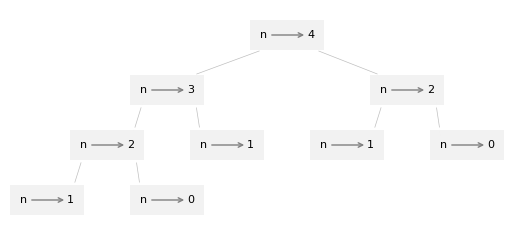

In [ ]:
from shared.diagram import diagram, adjust, Bbox

width, height, x, y = [4.94, 2.16, -1.03, 1.91]
ax = diagram(width, height)

dx = 0.6
dy = 0.55

bboxes = []
bboxes.append(frames[4].draw(ax, x+6*dx, y))

bboxes.append(frames[3].draw(ax, x+4*dx, y-dy))
bboxes.append(frames[2].draw(ax, x+8*dx, y-dy))

bboxes.append(frames[2].draw(ax, x+3*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+5*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+7*dx, y-2*dy))
bboxes.append(frames[0].draw(ax, x+9*dx, y-2*dy))

bboxes.append(frames[1].draw(ax, x+2*dx, y-3*dy))
bboxes.append(frames[0].draw(ax, x+4*dx, y-3*dy))

left_arrow(ax, bboxes[0], bboxes[1])
left_arrow(ax, bboxes[1], bboxes[3])
left_arrow(ax, bboxes[3], bboxes[7])
left_arrow(ax, bboxes[2], bboxes[5])

right_arrow(ax, bboxes[0], bboxes[2])
right_arrow(ax, bboxes[1], bboxes[4])
right_arrow(ax, bboxes[2], bboxes[6])
right_arrow(ax, bboxes[3], bboxes[8])

bbox = Bbox.union(bboxes)
# adjust(x, y, bbox)

A call graph shows a set of function frames, with lines connecting each frame to the frames of the functions it calls.
At the top of the graph, `fibonacci` with `n=4` calls `fibonacci` with ` n=3` and `n=2`.
In turn, `fibonacci` with `n=3` calls `fibonacci` with `n=2` and `n=1`. And so on.

Count how many times `fibonacci(0)` and `fibonacci(1)` are called. 
This is an inefficient solution to the problem, and it gets worse as the argument gets bigger.

One solution is to keep track of values that have already been computed by storing them in a dictionary.
A previously computed value that is stored for later use is called a **memo**.
Here is a "memoized" version of `fibonacci`:

In [ ]:
known = {0:0, 1:1}

def fibonacci_memo(n):
    if n in known:
        return known[n]

    res = fibonacci_memo(n-1) + fibonacci_memo(n-2)
    known[n] = res
    return res

`known` is a dictionary that keeps track of the Fibonacci numbers we already know
It starts with two items: `0` maps to `0` and `1` maps to `1`.

Whenever `fibonacci_memo` is called, it checks `known`.
If the result is already there, it can return immediately.
Otherwise it has to compute the new value, add it to the dictionary, and return it.

Comparing the two functions, `fibonacci(40)` takes about 30 seconds to run.
`fibonacci_memo(40)` takes about 30 microseconds, so it's a million times faster.
In the notebook for this chapter, you'll see where these measurements come from.

In [ ]:
# %time fibonacci(40)

In [ ]:
%time fibonacci_memo(40)

CPU times: user 8 μs, sys: 1e+03 ns, total: 9 μs
Wall time: 9.06 μs


102334155

### Common Dictionary Patterns


### Accumulating Results from Dictionary Data

For many programming tasks, it is useful to loop through one list or dictionary while building another.
As an example, we'll loop through the words in `word_dict` and make a list of palindromes -- that is, words that are spelled the same backward and forward, like "noon" and "rotator".

In the previous chapter, one of the exercises asked you to write a function that checks whether a word is a palindrome.
Here's a solution that uses `reverse_word`.


```{index} accumulator pattern, filter
```

In [ ]:
def is_palindrome(word):
    """Check if a word is a palindrome."""
    return reverse_word(word) == word

If we loop through the words in `word_dict`, we can count the number of palindromes like this.

In [ ]:
count = 0

for word in word_dict:
    if is_palindrome(word):
        count +=1
        
count

91

By now, this pattern is familiar.

* Before the loop, `count` is initialized to `0`.

* Inside the loop, if `word` is a palindrome, we increment `count`.

* When the loop ends, `count` contains the total number of palindromes.

We can use a similar pattern to make a list of palindromes.

In [ ]:
palindromes = []

for word in word_dict:
    if is_palindrome(word):
        palindromes.append(word)

palindromes[:10]

['aa', 'aba', 'aga', 'aha', 'ala', 'alula', 'ama', 'ana', 'anna', 'ava']

Here's how it works:

* Before the loop, `palindromes` is initialized with an empty list.

* Inside the loop, if `word` is a palindrome, we append it to the end of `palindromes`.

* When the loop ends, `palindromes` is a list of palindromes.

In this loop, `palindromes` is used as an **accumulator**, which is a variable that collects or accumulates data during a computation.

Now suppose we want to select only palindromes with seven or more letters.
We can loop through `palindromes` and make a new list that contains only long palindromes.

In [ ]:
long_palindromes = []

for word in palindromes:
    if len(word) >= 7:
        long_palindromes.append(word)
        
long_palindromes

['deified', 'halalah', 'reifier', 'repaper', 'reviver', 'rotator', 'sememes']

Looping through a list like this, selecting some elements and omitting others, is called **filtering**.

### Hashable Keys and Best Practices


### Lists as Values and Hashable Keys

You can put a list in a dictionary as a value.
For example, here's a dictionary that maps from the number `4` to a list of four letters.


In [ ]:
d = {4: ['r', 'o', 'u', 's']}
d

{4: ['r', 'o', 'u', 's']}

But you can't put a list in a dictionary as a key.
Here's what happens if we try.

In [ ]:
%%expect TypeError
letters = list('abcd')
d[letters] = 4


I mentioned earlier that dictionaries use hash tables, and that means that the keys have to be **hashable**.

A **hash** is a function that takes a value (of any kind) and returns an integer.
Dictionaries use these integers, called hash values, to store and look up keys.

This system only works if a key is immutable, so its hash value is always the same.
But if a key is mutable, its hash value could change, and the dictionary would not work.
That's why keys have to be hashable, and why mutable types like lists aren't.

Since dictionaries are mutable, they can't be used as keys, either.
But they *can* be used as values.

### Tuple Keys

An object is hashable if its hash value stays the same during its lifetime. An `id()` is the memory address of the object -- unique per object, but can be reused after an object is deleted.
`hash()` is a number derived from the object's contents or value, used for fast lookups.
Hashable objects can be used as dictionary keys and stored in sets.
A key rule is: if `a == b`, then `hash(a) == hash(b)`.

**Hashability caveat:** a tuple is hashable only if all of its elements are hashable.
If a tuple contains a list (or another unhashable type), it cannot be used as a dictionary key.


```{index} tuple; as dict key, hashable keys
```

A hash value is just an integer that represents an object, computed by the `hash()` function. 

| Type(s) | Mutability/Conditional | Hashable | Example |
|---|---|---|---|
| `int`, `float`, `bool`, `complex` | Immutable | Yes | `42`, `3.14`, `True`, `2+3j` |
| `str` | Immutable | Yes | `"hello"` |
| `tuple` | Immutable, conditional on all elements being hashable | Yes (conditional) | `(1, "a")` yes, `([1], "a")` no |
| `frozenset` | Immutable, conditional on all elements being hashable | Yes (conditional) | `frozenset({1, 2})` |
| `bytes` | Immutable | Yes | `b"abc"` |
| `None` | Immutable singleton | Yes | `None` |
| Functions, classes | Identity-based objects | Yes (by identity) | `len`, `dict` |
| `list` | Mutable | No | `[1, 2, 3]` |
| `dict` | Mutable | No | `{"a": 1}` |
| `set` | Mutable | No | `{1, 2, 3}` |
| `bytearray` | Mutable | No | `bytearray(b"abc")` |


Here are a few quick checks. Equal tuples have equal hashes, and tuples of hashable elements are hashable.

In [ ]:
a = (1, 2)
b = (1, 2)
a == b, hash(a) == hash(b)      ### return True, True

hash((1, (2, 3)))               ###  hashes a nested tuple, returning the large number shown

7267574591690527098

In [ ]:
%%expect TypeError
mixed = (1, [2, 3])
d = {mixed: 'not hashable'}


In [ ]:
### Exercise: Hashable Tuples
#   1. Create a dictionary that uses tuples as keys to map (row, col) grid positions
#      to string values: (0,0)->'start', (1,2)->'middle', (2,2)->'end'.
#   2. Print the value at position (1, 2).
#   3. Try to use ([0, 0],) as a key — wrap it in a try/except and print the error type.
### Your code starts here.




### Your code ends here.

In [ ]:
grid = {(0,0): 'start', (1,2): 'middle', (2,2): 'end'}
print(grid[(1, 2)])    # 'middle'

try:
    bad = {([0, 0],): 'unhashable'}
except TypeError as e:
    print(type(e).__name__, e)

middle
TypeError unhashable type: 'list'
